In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import xarray as xr
import numpy as np
from distributed import Client, LocalCluster
import dask
import pickle
import os
from scipy.stats import linregress
from matplotlib.lines import Line2D
from scipy.stats import linregress
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C, Matern, RationalQuadratic
import joblib # For saving our models
import time
import emcee
from matplotlib.ticker import FuncFormatter
import numpy as np
import pickle
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import string
import matplotlib.patches as mpatches
plt.rcParams['text.usetex'] = True
import corner # The library for creating corner plots

# Loadings neaded for LaTex

In [4]:
# Get the current PATH
original_path = os.environ.get('PATH', '')
latex_path = '/glade/u/apps/casper/24.12/spack/opt/spack/texlive/20240312/gcc/12.4.0/nm7e/bin/x86_64-linux' 
# Prepend the LaTeX path to the system's PATH
# We prepend it to make sure it's found first.
os.environ['PATH'] = latex_path + os.pathsep + original_path
plt.rcParams['text.usetex'] = True

# Load regime & control dataframes

In [5]:
read_path='/glade/u/home/mckenna/work/regime_dataframes/'
#df_regime2 = pd.read_pickle(read_path+'df_regime2_perturbed_members.pkl')
df_regime2 = pd.read_pickle(read_path+'df_regime2_perturbed_members_msp2.pkl')
#df_cntl_regime2 = pd.read_pickle(read_path+'df_regime2_cntl.pkl')
df_cntl_regime2 = pd.read_pickle(read_path+'df_regime2_cntl_msp2.pkl')
print(df_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
print(df_cntl_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)

                  0          1          2           3          4          5   \
RESTOM_PD  22.767999  10.145342  17.262480   -6.977647  21.915214  21.711642   
LWP_PD      3.057743  37.931980  10.159395  147.974965   5.190044   4.751587   
WROF_PD     0.799337   0.885769   0.920615    0.054271   0.803136   0.778199   
PAF_PD      0.005089   0.004556   0.004543    0.063875   0.002875   0.003208   

                   6          7          8           9   ...         40  \
RESTOM_PD   -7.650290  19.457138  14.639741   -2.185409  ...  -1.116216   
LWP_PD     148.395507  13.462151  14.315497  110.949258  ...  86.064168   
WROF_PD      0.053720   0.941904   0.942558    0.342422  ...   0.520146   
PAF_PD       0.062392   0.010737   0.009245    0.015458  ...   0.008924   

                   41         42          43         44         45         46  \
RESTOM_PD   -7.637161  23.359594   -7.432411  16.070160  16.228917  19.658779   
LWP_PD     148.083371   4.195462  148.166729  15.888349  10.1

# Generate dense priors

In [6]:
# Boolean that determines whether or not we propagate the emulator's error through the dense prior.
# This means that if set to False, each value in the dense prior distribution (which is randomly sampled without a functional assumption),
#   will be the mean of the emulator prediction. If True, it instead samples from the Gaussian distirbution provided by the emulator's mean and standard deviation.
sample_bool = True

# --- 1. Configuration & Setup ---
print("--- Step 1: Configuration & Setup ---")

regime_str = 'regime2'

#scaler_path = './emulators_production/global_x_scaler.joblib'
scaler_path = './emulators_production_msp2/global_x_scaler_msp2.joblib'
#transform_file = './emulators_production/production_transforms.joblib'
transform_file = './emulators_production_msp2/production_transforms_msp2.joblib'
transforms = joblib.load(transform_file)

# Number of samples for dense prior
N_DENSE_SAMPLES = 1_000_000
np.random.seed(42)

#VAR_NAMES = [
#    'LWP_PD', 'CDNC_PD', 'REFF_PD', 'GLOBAL_LCC_PD', 'WROF_PD', 'PAF_PD','PRECL_PD', 'AUTOCONV_PD', 'ACCRETN_PD',
#    'LWP_adj', 'CDNC_adj', 'REFF_adj', 'GLOBAL_LCC_adj', 'WROF_adj', 'PAF_adj', 'PRECL_adj', 'AUTOCONV_adj','ACCRETN_adj',
#    'ERF_ACI', 'ERF_TOT', 'CRE_PD', 'CRE_adj', 'RESTOM_PD', 'OLR_NET_PD',
#    'OSR_NET_PD', 'OLR_UPWELL_PD', 'OSR_UPWELL_PD', 'CRF_LW_PD', 'CRF_SW_PD'
#]

VAR_NAMES = ['OLR_UPWELL_PD','OSR_UPWELL_PD','RESTOM_PD','ERF_ACI','LWP_PD','LWP_adj','AUTOCONV_PD','ACCRETN_PD','PRECL_PD','WROF_PD','PAF_PD']


# --- 2. Load Emulators and Scaler ---
print("--- Step 2: Loading Emulators and Scaler ---")
scaler = joblib.load(scaler_path)

emulators = {}
for var in VAR_NAMES:
    #filepath = f'./emulators_production/gp_production_{var}.joblib'
    filepath = f'./emulators_production_msp2/gp_production_{var}_msp2.joblib'
    if os.path.exists(filepath):
        emulators[var] = joblib.load(filepath)
    else:
        print(f"Warning: Emulator file not found for {var}, skipping.")

print(f"Successfully loaded {len(emulators)} emulators.")


# --- 3. Generate the Original PPE Prior (Sparse Prior) ---
print("--- Step 3: Generating the Sparse PPE Prior ---")
original_ppe_priors = {}
for var in VAR_NAMES:
    if var in df_regime2.columns:
        original_ppe_priors[var] = df_regime2[var].to_numpy()

# --- 4. Generate the Dense Prior ---
print("--- Step 4: Generating the Dense Prior ---")

# Create random samples in the scaled [0, 1] input space
# This is the space the emulators were trained on.
# Bounds in regular space
valid_lower_log = np.log10([2**-8., 2**-8.])  # Lower bounds in log10 space
valid_upper_log = np.log10([2**8., 2**8.])    # Upper bounds in log10 space

# Ensure the input is reshaped for the scaler (expecting 2D input: (n_samples, n_features))
valid_lower_scaled = scaler.transform(valid_lower_log.reshape(1, -1))[0]  # Scaled lower bound
valid_upper_scaled = scaler.transform(valid_upper_log.reshape(1, -1))[0]  # Scaled upper bound

# Set mean and standard deviation for the normal distribution
mean = (valid_lower_scaled + valid_upper_scaled) / 2  # Center of the bounds
std_dev = np.abs(valid_upper_scaled - valid_lower_scaled) / 6  # Spread (approx 99.7%)

# Generate samples and clip them to stay within bounds
#param_samples_scaled = np.random.normal(loc=mean, scale=std_dev, size=(N_DENSE_SAMPLES, 2))    
param_samples_scaled = np.random.rand(N_DENSE_SAMPLES, 2)

# --- 5a. Define All Physical Bounds in a Central Dictionary ---
# For any variable not in this map, the bounds will be (-inf, inf).
bounds_map = {
    # Variables with only a lower bound of 0
    'PRECL_PD': (0, np.inf),
    'LWP_PD':   (0, np.inf),
    'AUTOCONV_PD':  (0, np.inf),
    'ACCRETN_PD':  (0, np.inf),
    'WROF_PD':  (0, 1),
    'PAF_PD':  (0, 1),
}

# --- 5b.  Dense Prior Generation Loop ---
dense_priors = {}
for var_name, emulator in emulators.items():
    print(f"  - Predicting for {var_name}...")
    mean_pred, std_pred = emulator.predict(param_samples_scaled, return_std=True)
    
    # This is the variable that will hold the final samples
    prior_samples = None 

    if transforms.get(var_name) == 'log':
        if sample_bool:
            # 1. Sample from the simple normal distribution IN LOG SPACE
            log_samples = np.random.normal(loc=mean_pred, scale=std_pred)
            # 2. Transform the final samples back to linear space
            prior_samples = np.exp(log_samples)
        else:
            # If not sampling, just transform the mean
            prior_samples = np.exp(mean_pred)
            
    else: # This block is for all non-log variables
        # Use a small epsilon to prevent division by zero if std_pred is 0
        std_pred[std_pred == 0] = 1e-20
        
        if var_name in bounds_map:
            # It's a bounded variable, so use truncnorm
            lower_bound, upper_bound = bounds_map[var_name]
            a = (lower_bound - mean_pred) / std_pred
            b = (upper_bound - mean_pred) / std_pred
            if sample_bool:
                prior_samples = stats.truncnorm.rvs(a, b, loc=mean_pred, scale=std_pred)
            else:
                prior_samples = mean_pred
        else:
            # It's an unbounded variable
            if sample_bool:
                prior_samples = np.random.normal(loc=mean_pred, scale=std_pred)
            else:
                prior_samples = mean_pred
        
    dense_priors[var_name] = prior_samples

print("Dense prior generation complete with robust bounds.")

--- Step 1: Configuration & Setup ---
--- Step 2: Loading Emulators and Scaler ---
Successfully loaded 11 emulators.
--- Step 3: Generating the Sparse PPE Prior ---
--- Step 4: Generating the Dense Prior ---
  - Predicting for OLR_UPWELL_PD...
  - Predicting for OSR_UPWELL_PD...
  - Predicting for RESTOM_PD...
  - Predicting for ERF_ACI...
  - Predicting for LWP_PD...
  - Predicting for LWP_adj...
  - Predicting for AUTOCONV_PD...
  - Predicting for ACCRETN_PD...
  - Predicting for PRECL_PD...
  - Predicting for WROF_PD...
  - Predicting for PAF_PD...
Dense prior generation complete with robust bounds.


## Save the dense prior dictionary to a pickle file

In [7]:
save_path='/glade/u/home/mckenna/work/'
#with open(save_path+'dense_priors_dict.pkl', 'wb') as file:
with open(save_path+'dense_priors_dict_msp2.pkl', 'wb') as file:
    pickle.dump(dense_priors, file)

# Read in dense priors

In [8]:
read_path='/glade/u/home/mckenna/work/'
#with open(read_path+'dense_priors_dict.pkl', 'rb') as file:
with open(read_path+'dense_priors_dict_msp2.pkl', 'rb') as file:
    dense_priors = pickle.load(file)
df_dense_priors = pd.DataFrame.from_dict(dense_priors)

## Recall sparse PPE priors

In [9]:
VAR_NAMES = ['OLR_UPWELL_PD','OSR_UPWELL_PD','RESTOM_PD','ERF_ACI','LWP_PD','LWP_adj','AUTOCONV_PD','ACCRETN_PD','PRECL_PD','WROF_PD','PAF_PD']
original_ppe_priors = {}
for var in VAR_NAMES:
    if var in df_regime2.columns:
        original_ppe_priors[var] = df_regime2[var].to_numpy()

# Plot Sparse & Dense Prior PDFs

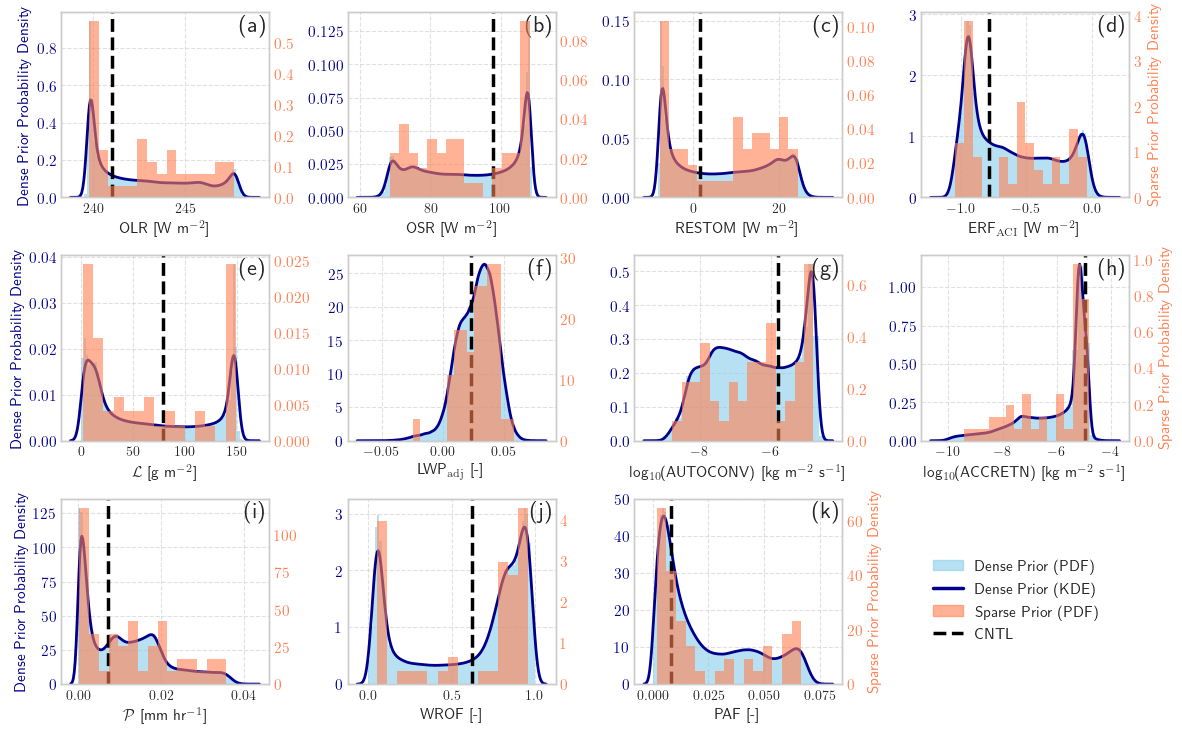

done


In [12]:
# Assume dense_priors, original_ppe_priors, and df_cntl_regime2 are loaded.
# --- 1. Define Plot Configuration ---
plot_vars_metadata = [
    {'key': 'OLR_UPWELL_PD', 'title': r'OLR', 'units': r'W m$^{-2}$','lab':r'OLR'},
    {'key': 'OSR_UPWELL_PD', 'title': r'OSR', 'units': r'W m$^{-2}$','lab':r'OSR'},
    {'key': 'RESTOM_PD', 'title': r'RESTOM', 'units': r'W m$^{-2}$','lab':r'RESTOM'},
    {'key': 'ERF_ACI', 'title': r'Effective Radiative Forcing (ERF$_{\mathrm{ACI}}$)', 'units': r'W m$^{-2}$','lab':r'ERF$_{\mathrm{ACI}}$'},
    {'key': 'LWP_PD', 'title': r'Liquid Water Path ($\mathcal{L}$)', 'units': r'g m$^{-2}$','lab':r'$\mathcal{L}$'},
    {'key': 'LWP_adj', 'title': r':LWP$_{\mathrm{adj}}$', 'units': r'-','lab':r'LWP$_{\mathrm{adj}}$'},
    {'key': 'AUTOCONV_PD', 'title': r'Vertically Integrated Autoconversion Rate (AUTOCONV)', 'units': r'kg m$^{-2}$ s$^{-1}$','lab':r'AUTOCONV'},
    {'key': 'ACCRETN_PD', 'title': r'Vertically Integrated Accretion Rate (ACCRETN)', 'units': r'kg m$^{-2}$ s$^{-1}$','lab':r'ACCRETN'},
    {'key': 'PRECL_PD', 'title': r'Large-Scale Precipitation (PRECL)', 'units': r'mm hr$^{-1}$','lab':r'$\mathcal{P}$'},
    {'key': 'WROF_PD', 'title': r'Warm-Rain Occurrence Frequency (WROF)', 'units': r'-','lab':r'WROF'},
    {'key': 'PAF_PD', 'title': r'Precipitation Amplification Frequency (PAF)', 'units': r'-','lab':r'PAF'},
]

# --- 2. Create the Figure ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes_flat = axes.ravel()
Fontsize = 11
N_COLS = 4

# --- 3. Main Plotting Loop ---
for i, var_meta in enumerate(plot_vars_metadata):
    ax1 = axes_flat[i]
    key = var_meta['key']
    lab = var_meta['lab']

    if key in dense_priors and key in original_ppe_priors:
        dense_data = dense_priors[key]
        sparse_data = original_ppe_priors[key]
        is_process_rate = (key == 'AUTOCONV_PD') or (key == 'ACCRETN_PD')

        if is_process_rate:
            dense_data_log = np.log10(dense_data + 1e-20)
            sparse_data_log = np.log10(sparse_data + 1e-20)
            cntl_value_log = np.log10(df_cntl_regime2[key].iloc[0] + 1e-20)

            ax1.hist(dense_data_log, bins=30, density=True, color='skyblue', alpha=0.6)
            sns.kdeplot(x=dense_data_log, ax=ax1, color='darkblue', lw=2.)
            ax1.tick_params(axis='y', labelcolor='darkblue', labelsize=Fontsize)

            ax2 = ax1.twinx()
            ax2.hist(sparse_data_log, bins=15, density=True, color='coral', alpha=0.6)
            #sns.kdeplot(x=sparse_data_log, ax=ax2, color='coral', lw=2., linestyle='-')
            ax2.tick_params(axis='y', labelcolor='coral', labelsize=Fontsize)
            
            ax1.axvline(cntl_value_log, lw=2.5, c='k', ls='dashed', label='CNTL')
            ax1.set_xlabel(f"log$_{{10}}$({lab}) [{var_meta['units']}]", fontsize=Fontsize)
        else:
            cntl_value = df_cntl_regime2[key].iloc[0]

            ax1.hist(dense_data, bins=75, density=True, color='skyblue', alpha=0.6, label='Dense Prior (PDF)')
            sns.kdeplot(x=dense_data, ax=ax1, color='darkblue', lw=2., label='Dense Prior (KDE)')
            ax1.tick_params(axis='y', labelcolor='darkblue', labelsize=Fontsize)
            
            ax2 = ax1.twinx()
            ax2.hist(sparse_data, bins=15, density=True, color='coral', label='Sparse Prior (PDF)', alpha=0.6)
            #sns.kdeplot(x=sparse_data, ax=ax2, color='coral', lw=2., linestyle='-', label='Sparse Prior (KDE)')
            ax2.tick_params(axis='y', labelcolor='coral', labelsize=Fontsize)
            
            ax1.axvline(cntl_value, lw=2.5, c='k', ls='dashed', label='CNTL')
            ax1.set_xlabel(f"{lab} [{var_meta['units']}]", fontsize=Fontsize)

        ax1.grid(True, linestyle='--', alpha=0.6)
        ax2.grid(False)

        ### --- START: CORRECTED Y-AXIS LABEL CONTROL --- ###
        col_idx = i % N_COLS
        
        # (1) Primary y-axis labels only for the first column
        if col_idx == 0:
            ax1.set_ylabel('Dense Prior Probability Density', fontsize=Fontsize, color='darkblue')
        else:
            # Only hide the label text, not the tick numbers
            ax1.set_ylabel('')

        # (2) Secondary (twin) y-axis labels for last column OR the very last plotted panel
        ### THIS IS THE KEY LOGIC CHANGE ###
        if col_idx == N_COLS - 1 or i == len(plot_vars_metadata) - 1:
             ax2.set_ylabel('Sparse Prior Probability Density', fontsize=Fontsize, color='coral')
        else:
            # Only hide the label text, not the tick numbers
            ax2.set_ylabel('')
        ### --- END: CORRECTED Y-AXIS LABEL CONTROL --- ###

    else:
        ax1.text(0.5, 0.5, f'Data for "{key}" not found', ha='center', va='center')

# Final cleanup
axes_flat[-1].remove()

# Legend setup (unchanged)
dense_hist_proxy = mpatches.Patch(color='skyblue', alpha=0.6, label='Dense Prior (PDF)')
sparse_hist_proxy = mpatches.Patch(color='coral', alpha=0.6, label='Sparse Prior (PDF)')
dense_kde_proxy = mlines.Line2D([], [], color='darkblue', lw=2.5, label='Dense Prior (KDE)')
#sparse_kde_proxy = mlines.Line2D([], [], color='coral', lw=2.5, label='Sparse Prior (KDE)')
cntl_proxy = mlines.Line2D([], [], color='k', linestyle='--', lw=2.5, label='CNTL')
lgnd = axes_flat[10].legend(
    #handles=[dense_hist_proxy, dense_kde_proxy, sparse_hist_proxy, sparse_kde_proxy, cntl_proxy],
    handles=[dense_hist_proxy, dense_kde_proxy, sparse_hist_proxy, cntl_proxy],
    loc='upper right',
    fontsize=Fontsize,
    bbox_to_anchor=(2.3, 0.75),
)
lgnd.set_in_layout(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])

panel_labels = string.ascii_lowercase
for i,ax in enumerate(axes_flat):
        ax.text(0.99,0.99,rf'({panel_labels[i]})',transform=ax.transAxes,fontsize=Fontsize*1.5,va='top',ha='right')

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'sparse_dense_prior_dists.png'
#plt.savefig(save_path+file_name,dpi=300)
plt.show()
plt.close()
print('done')

# Plot correlation matrix of sparse priors and dense priors

--- DataFrame after log transformation (first 5 rows) ---
   OLR_UPWELL_PD  OSR_UPWELL_PD      LWP_PD  log10(AUTOCONV_PD)  \
0     247.142773      70.498618    3.057743           -5.898672   
1     242.623929      87.641271   37.931980           -6.228395   
2     244.919465      78.228014   10.159395           -5.425590   
3     239.807424     107.582677  147.974965           -8.081332   
4     246.855481      71.638781    5.190044           -6.596832   

   log10(ACCRETN_PD)  PRECL_PD   WROF_PD    PAF_PD  
0          -5.210877  0.008559  0.799337  0.005089  
1          -4.810494  0.021446  0.885769  0.004556  
2          -5.166911  0.013925  0.920615  0.004543  
3          -7.867277  0.000288  0.054271  0.063875  
4          -5.206672  0.012190  0.803136  0.002875  


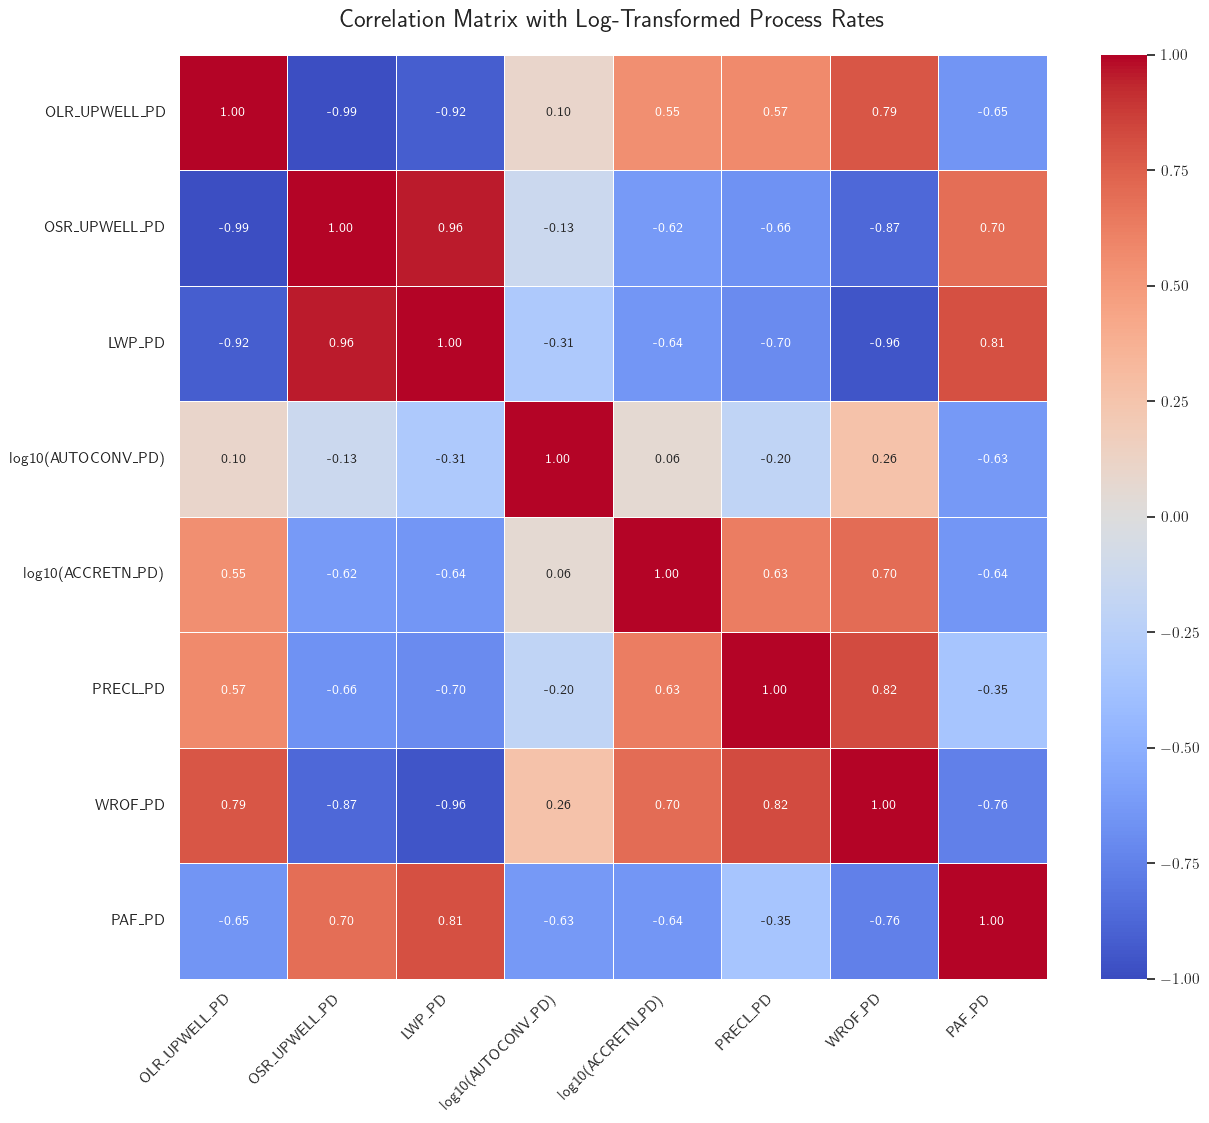

In [13]:
# ==============================================================================
# 1. DEFINE VARIABLES AND PREPARE DATA
# ==============================================================================

# Your full list of variables for the matrix
constraining_vars = ['OLR_UPWELL_PD', 'OSR_UPWELL_PD', 'LWP_PD','AUTOCONV_PD', 'ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']

# The specific variables to be log-transformed
vars_to_log = ['AUTOCONV_PD', 'ACCRETN_PD']

# Create a fresh subset of your data
subset_df = df_regime2[constraining_vars].copy()

# ==============================================================================
# 2. APPLY THE LOGARITHMIC TRANSFORMATION
# ==============================================================================

# This loop applies the log10 transform and renames the columns for clarity
for var in vars_to_log:
    # Add a small epsilon to avoid log(0) errors if any data is zero
    #epsilon = 1e-12 
    epsilon = 0
    subset_df[var] = np.log10(subset_df[var] + epsilon)
    
    # Rename the column to reflect the transformation
    subset_df.rename(columns={var: f'log10({var})'}, inplace=True)

print("--- DataFrame after log transformation (first 5 rows) ---")
print(subset_df.head())

# ==============================================================================
# 3. COMPUTE AND VISUALIZE THE CORRELATION MATRIX
# ==============================================================================

# Compute the correlation matrix on the transformed data
corr_matrix = subset_df.corr()

# Visualize it as a heatmap
plt.figure(figsize=(14, 12)) # Increased size for better readability
sns.set_theme(style="white") # Set a clean theme

heatmap = sns.heatmap(
    corr_matrix, 
    annot=True,       # Show the correlation values on the heatmap
    cmap='coolwarm',    # A diverging colormap is great for correlations
    fmt='.2f',        # Format annotations to two decimal places
    vmin=-1, vmax=1,  # Anchor the colormap from -1 to 1
    linewidths=.5,    # Add thin lines between cells
    annot_kws={"size": 10} # Adjust font size of annotations if needed
)

plt.title('Correlation Matrix with Log-Transformed Process Rates', fontsize=18, pad=20)
# Improve label readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

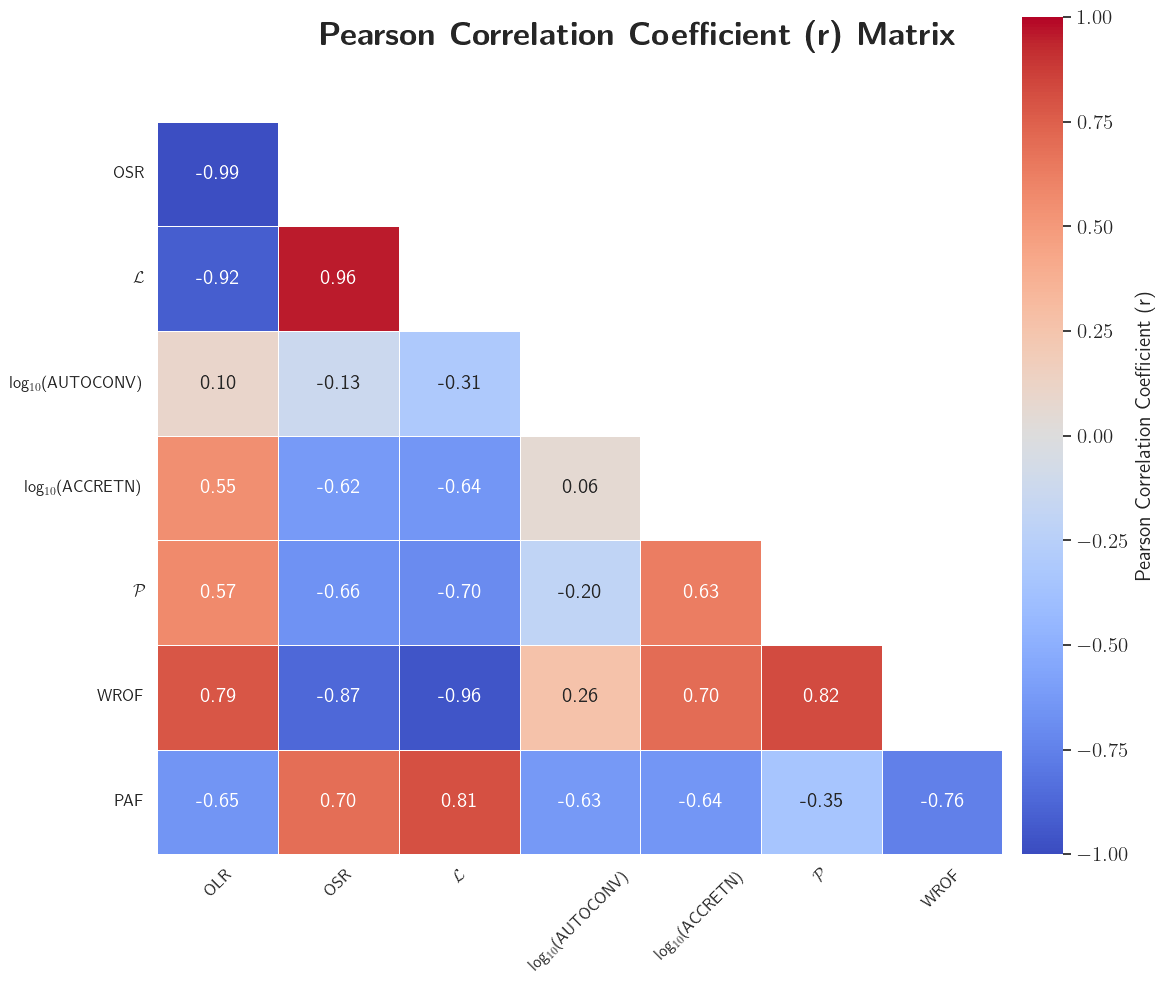

done


In [14]:
# ==============================================================================
# 1. SETUP: Assume df_regime2 and df_dense_priors are loaded
# ==============================================================================
# Define the variables and the log-transformation list
constraining_vars = ['OLR_UPWELL_PD', 'OSR_UPWELL_PD','LWP_PD','AUTOCONV_PD', 'ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']
vars_to_log = ['AUTOCONV_PD', 'ACCRETN_PD']

# ==============================================================================
# 2. CREATE A HELPER FUNCTION TO AVOID REPEATING CODE
# ==============================================================================
def prepare_and_correlate(df, all_vars, log_vars):
    """
    Takes a dataframe, selects columns, log-transforms specified ones,
    and returns the correlation matrix and nice labels.
    """
    subset_df = df[all_vars].copy()
    labels = list(subset_df.columns)
    
    for i, var in enumerate(all_vars):
        if var in log_vars:
            # Add a small epsilon for numerical stability with log
            subset_df[var] = np.log10(subset_df[var] + 1e-20) 
            labels[i] = f'log$_{{10}}$({var})'
            
    subset_df.columns = labels
    return subset_df.corr()


corr_sparse = prepare_and_correlate(df_regime2, constraining_vars, vars_to_log)

# Create a shared mask for the upper triangle
mask = np.triu(np.ones_like(corr_sparse, dtype=bool))

# Create a figure with two subplots, side-by-side
fig, ax1 = plt.subplots(1, 1, figsize=(12, 10))
sns.set_theme(style="white")
Fontsize=12

cbar_settings = {
    #'shrink': 1.,       # Make the colorbar 80% of the plot's height
    #'fraction': 0.04,      # Control the width (thinner than default)
    'pad': -0.1,         # Increase the distance from the main plot
    'label': 'Pearson Correlation Coefficient (r)' # Add the label
}

# --- Plot Panel (a): Sparse Prior ---
heatmap = sns.heatmap(
    corr_sparse, 
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1, vmax=1,
    linewidths=.5,
    annot_kws={"size": Fontsize*1.25},
    ax=ax1,  # Specify the left axis
    cbar=True,
    cbar_kws=cbar_settings,

)
ax1.set_title(r'\textbf{Pearson Correlation Coefficient (r) Matrix}', fontsize=Fontsize*2., pad=-20)
ax1.tick_params(axis='x', rotation=45, labelsize=Fontsize)
ax1.tick_params(axis='y', rotation=0, labelsize=Fontsize)

yticks = ax1.get_yticks()
ax1.set_yticks(yticks[1:])
xticks = ax1.get_xticks()
ax1.set_xticks(xticks[:-1])

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=Fontsize*1.25)
cbar.ax.yaxis.label.set_size(Fontsize*1.25)

yticklabels = ['OSR','$\mathcal{L}$','log$_{10}$(AUTOCONV)','log$_{10}$(ACCRETN)','$\mathcal{P}$','WROF','PAF']
ax1.set_yticklabels(yticklabels)
xticklabels = ['OLR','OSR','$\mathcal{L}$','log$_{10}$(AUTOCONV)','log$_{10}$(ACCRETN)','$\mathcal{P}$','WROF']
ax1.set_xticklabels(xticklabels)

# --- Final Adjustments ---
plt.tight_layout()

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'sparse_prior_correlation_matrix.png'
#plt.savefig(save_path+file_name,dpi=300)
plt.show()
plt.close()
print('done')

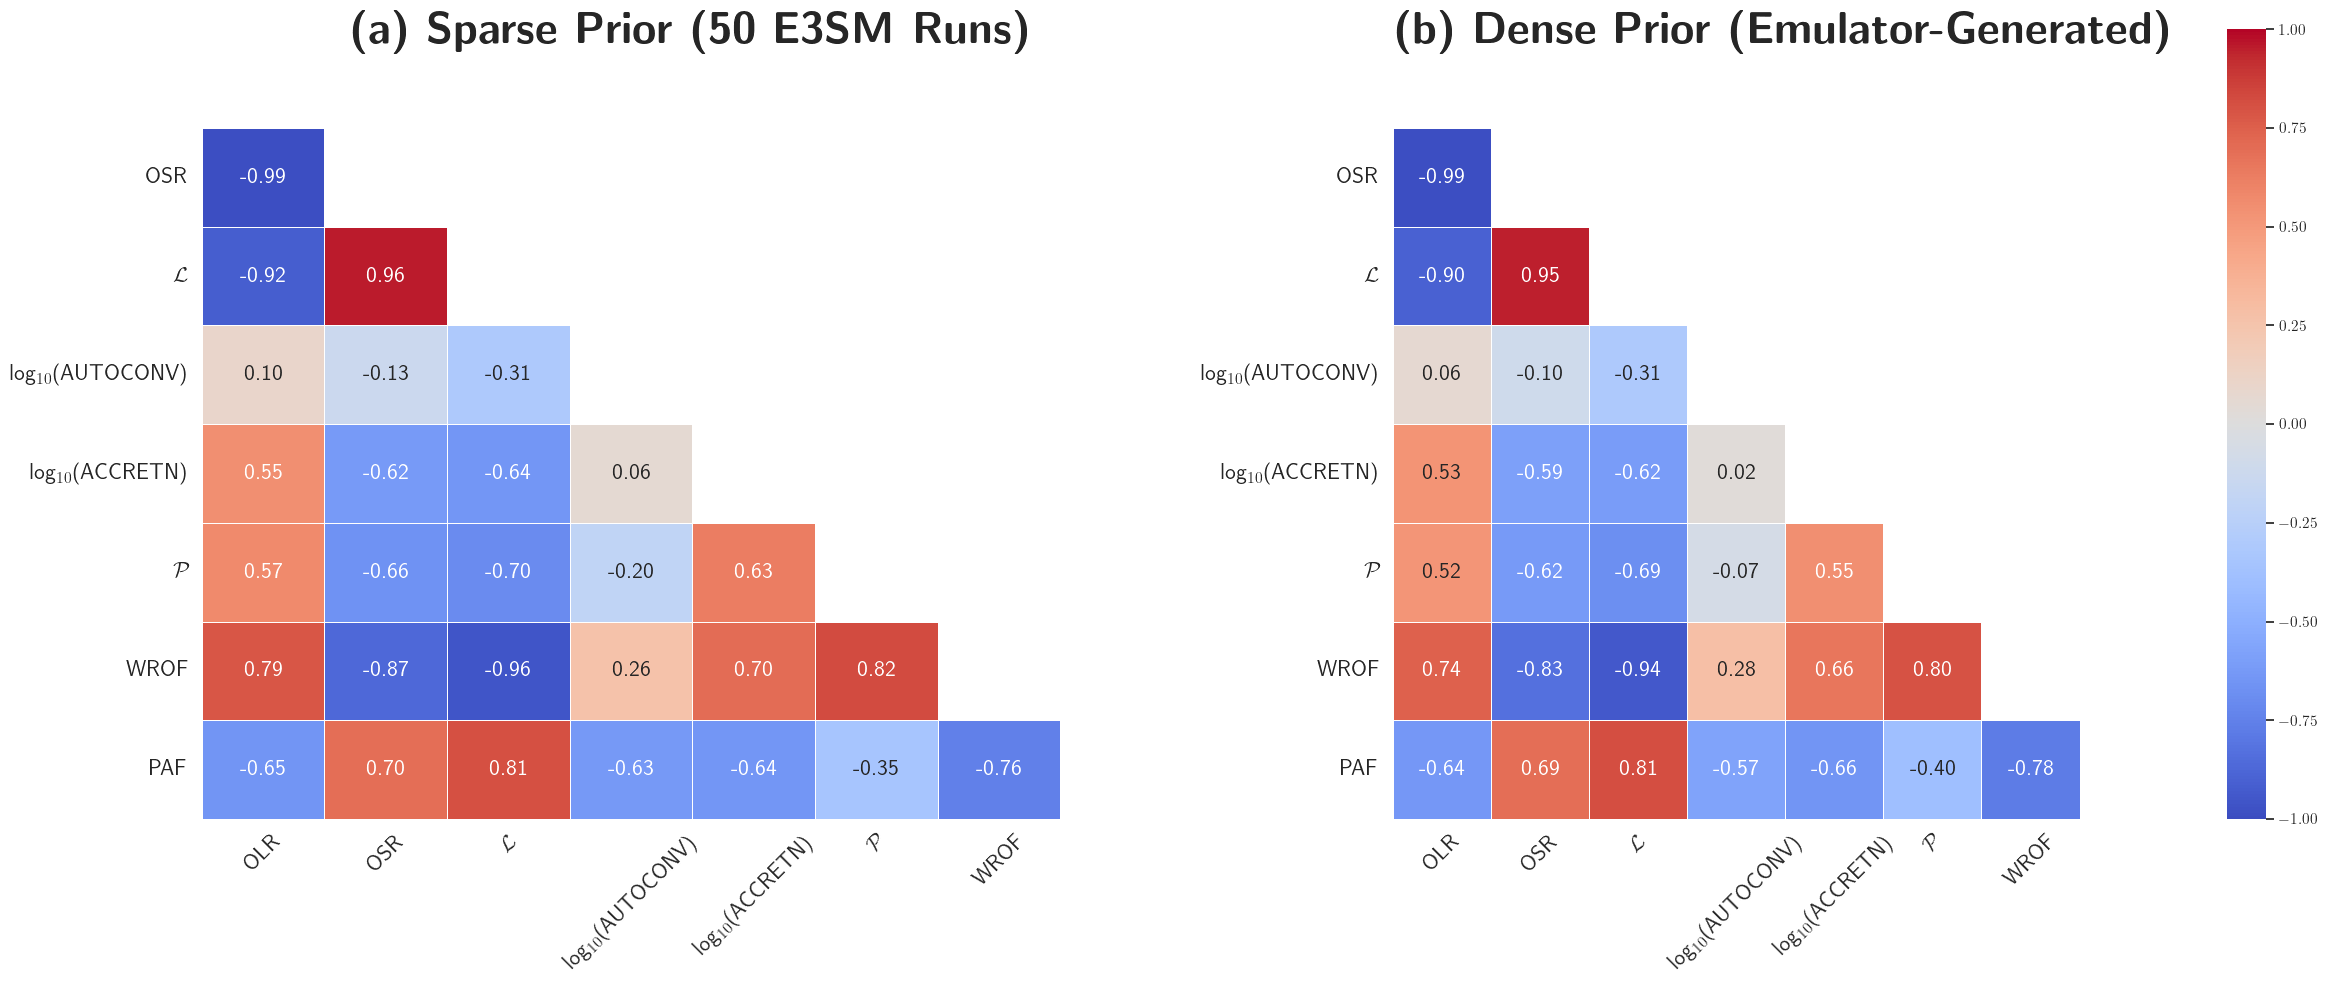

In [44]:
# ==============================================================================
# 1. SETUP: Assume df_regime2 and df_dense_priors are loaded
# ==============================================================================
# Define the variables and the log-transformation list
constraining_vars = ['OLR_UPWELL_PD', 'OSR_UPWELL_PD','LWP_PD','AUTOCONV_PD', 'ACCRETN_PD','PRECL_PD', 'WROF_PD', 'PAF_PD']
vars_to_log = ['AUTOCONV_PD', 'ACCRETN_PD']

# ==============================================================================
# 2. CREATE A HELPER FUNCTION TO AVOID REPEATING CODE
# ==============================================================================
def prepare_and_correlate(df, all_vars, log_vars):
    """
    Takes a dataframe, selects columns, log-transforms specified ones,
    and returns the correlation matrix and nice labels.
    """
    subset_df = df[all_vars].copy()
    labels = list(subset_df.columns)
    
    for i, var in enumerate(all_vars):
        if var in log_vars:
            # Add a small epsilon for numerical stability with log
            subset_df[var] = np.log10(subset_df[var] + 1e-20) 
            labels[i] = f'log$_{{10}}$({var})'
            
    subset_df.columns = labels
    return subset_df.corr()

# ==============================================================================
# 3. PREPARE DATA FOR BOTH PANELS
# ==============================================================================
# --- Panel (a): Sparse Prior (from the 50-member PPE) ---
corr_sparse = prepare_and_correlate(df_regime2, constraining_vars, vars_to_log)

# --- Panel (b): Dense Prior (from propagating random inputs through emulators) ---
corr_dense = prepare_and_correlate(df_dense_priors, constraining_vars, vars_to_log)

# Create a shared mask for the upper triangle
mask = np.triu(np.ones_like(corr_sparse, dtype=bool))

# ==============================================================================
# 4. CREATE THE TWO-PANEL FIGURE
# ==============================================================================
# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
sns.set_theme(style="white")
Fontsize=16
# --- Plot Panel (a): Sparse Prior ---
sns.heatmap(
    corr_sparse, 
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1, vmax=1,
    linewidths=.5,
    annot_kws={"size": Fontsize},
    ax=ax1,  # Specify the left axis
    cbar=False
)
ax1.set_title(r'\textbf{(a) Sparse Prior (50 E3SM Runs)}', fontsize=Fontsize*2., pad=-10)
ax1.tick_params(axis='x', rotation=45, labelsize=Fontsize)
ax1.tick_params(axis='y', rotation=0, labelsize=Fontsize)


# --- Plot Panel (b): Dense Prior ---
sns.heatmap(
    corr_dense, 
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1, vmax=1,
    linewidths=.5,
    annot_kws={"size": Fontsize},
    ax=ax2,  # Specify the right axis
    cbar=True # Turn off the colorbar for the second plot to avoid redundancy
)
ax2.set_title(r'\textbf{(b) Dense Prior (Emulator-Generated)}', fontsize=Fontsize*2., pad=-10)
ax2.tick_params(axis='x', rotation=45, labelsize=Fontsize)
ax2.tick_params(axis='y', rotation=0, labelsize=Fontsize)

#yticklabels

#ax2.set_yticks([]) # Remove y-axis ticks and labels for a cleaner look
yticks = ax2.get_yticks()
ax2.set_yticks(yticks[1:])
yticks = ax1.get_yticks()
ax1.set_yticks(yticks[1:])
xticks = ax1.get_xticks()
ax1.set_xticks(xticks[:-1])
xticks = ax2.get_xticks()
ax2.set_xticks(xticks[:-1])

yticklabels = ['OSR','$\mathcal{L}$','log$_{10}$(AUTOCONV)','log$_{10}$(ACCRETN)','$\mathcal{P}$','WROF','PAF']
ax1.set_yticklabels(yticklabels)
ax2.set_yticklabels(yticklabels)
xticklabels = ['OLR','OSR','$\mathcal{L}$','log$_{10}$(AUTOCONV)','log$_{10}$(ACCRETN)','$\mathcal{P}$','WROF']
ax1.set_xticklabels(xticklabels)
ax2.set_xticklabels(xticklabels)

# --- Final Adjustments ---
plt.tight_layout()
plt.show()